# Clustering Histórico Chat

---

## Objetivo

O objetivo desse notebook é realizar técnicas de Aprendizado Não Supervisionado para agrupar os vetores de embeddings processados no último notebook em clusters semânticos.

---

## Código

---

In [1]:
import numpy as np

emb_train = np.load("../artifacts/embedding/embeddings_train.npy")
emb_test = np.load("../artifacts/embedding/embeddings_test.npy")

In [2]:
import umap

umap_cluster_embedding = umap.UMAP(
    n_neighbors=30,
    n_components=10,
    min_dist=0.1,
    metric="cosine",      
    init="spectral",
    random_state=42,
    transform_seed=42,
    low_memory=False,         
    n_jobs=-1
)

umap_train_emb = umap_cluster_embedding.fit_transform(emb_train)
umap_test_emb = umap_cluster_embedding.transform(emb_test)

print(f"NaNs no Treino: {np.isnan(umap_train_emb).sum()}")
print(f"NaNs no Teste:  {np.isnan(umap_test_emb).sum()}")

/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


NaNs no Treino: 0
NaNs no Teste:  770


In [21]:
rng = np.random.default_rng()

idx = rng.choice(
    len(umap_train_emb),
    size=10_000,
    replace=False
)

umap_sample_emb = umap_train_emb[idx]

In [22]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

ks = [5, 10, 15, 20, 25, 30]

silhouettes = []
print("Iniciando Validação Por Silhuette")
for k in ks:
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        batch_size=2048,
        random_state=42,
        n_init=10
    )
    clusters_sample = kmeans.fit_predict(umap_sample_emb)
    score = silhouette_score(
        umap_sample_emb,
        clusters_sample,
        metric="euclidean"
    )
    silhouettes.append(score)
    print(f"k={k:2d} | Silhouette={score:.4f}")
print("Validação Concluída!")

Iniciando Validação Por Silhuette
k= 5 | Silhouette=0.2549
k=10 | Silhouette=0.2320
k=15 | Silhouette=0.1688
k=20 | Silhouette=0.2301
k=25 | Silhouette=0.2239
k=30 | Silhouette=0.2054
Validação Concluída!


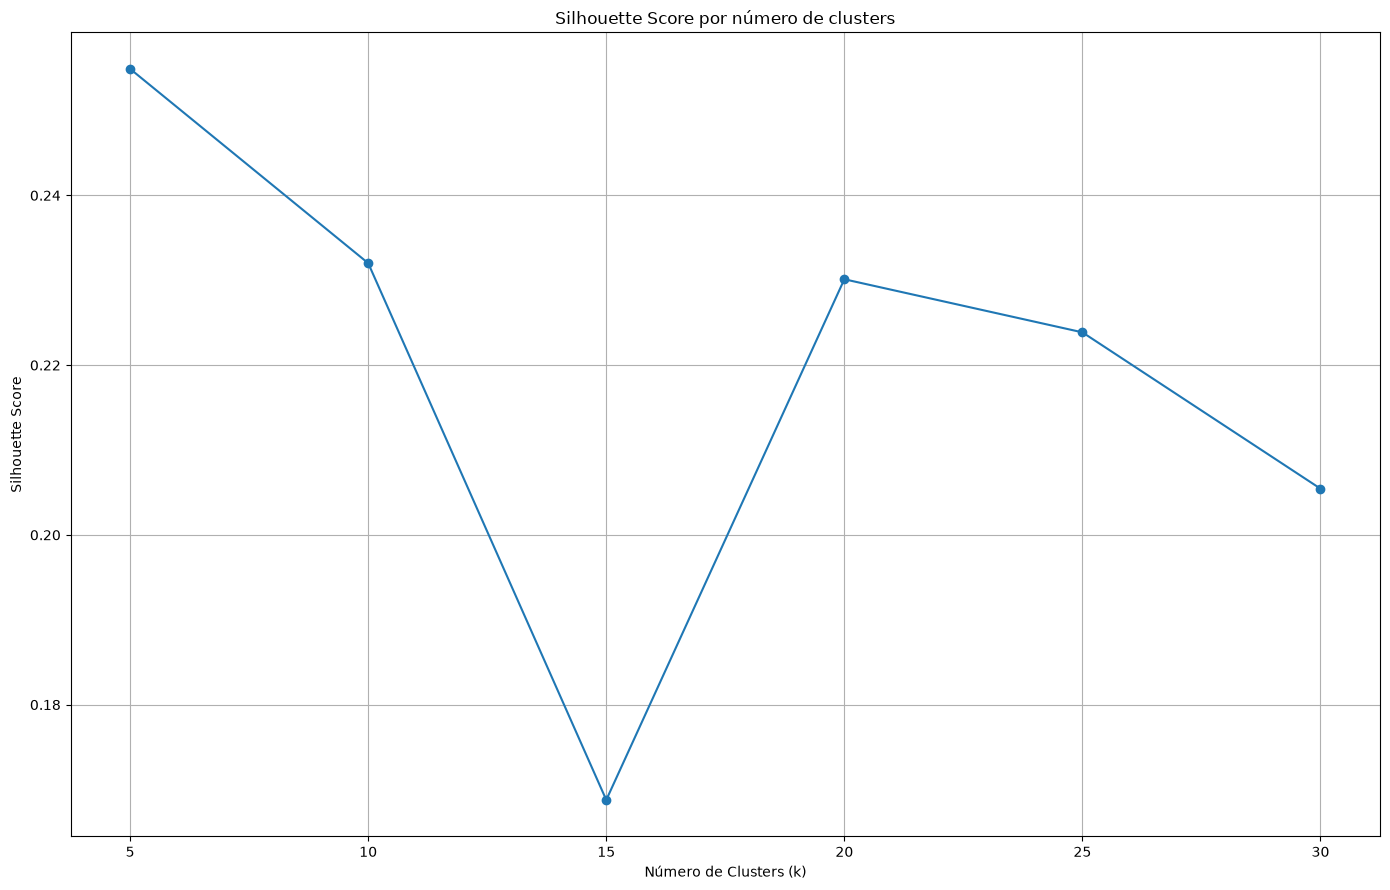

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 9))
plt.plot(ks, silhouettes, marker="o")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score por número de clusters")
plt.grid(True)
plt.tight_layout()

In [24]:
# 5 Clusters

kmeans_emb_5k = MiniBatchKMeans(
    n_clusters=5,
    batch_size=2048,
    random_state=42,
    n_init=10
)

clusters_emb_5k_train = kmeans_emb_5k.fit_predict(umap_train_emb)
clusters_emb_5k_test = kmeans_emb_5k.predict(umap_test_emb)

# 10 Clusters

kmeans_emb_10k = MiniBatchKMeans(
    n_clusters=10,
    batch_size=2048,
    random_state=42,
    n_init=10
)

clusters_emb_10k_train = kmeans_emb_10k.fit_predict(umap_train_emb)
clusters_emb_10k_test = kmeans_emb_10k.predict(umap_test_emb)

In [25]:
umap_vis = umap.UMAP(
    n_neighbors=30,
    n_components=2,
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
    n_jobs=-1,
)

coords_2d = umap_vis.fit_transform(umap_sample_emb)

/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [26]:
import pandas as pd

df_train = pd.read_parquet("../dados/processed/train.parquet")

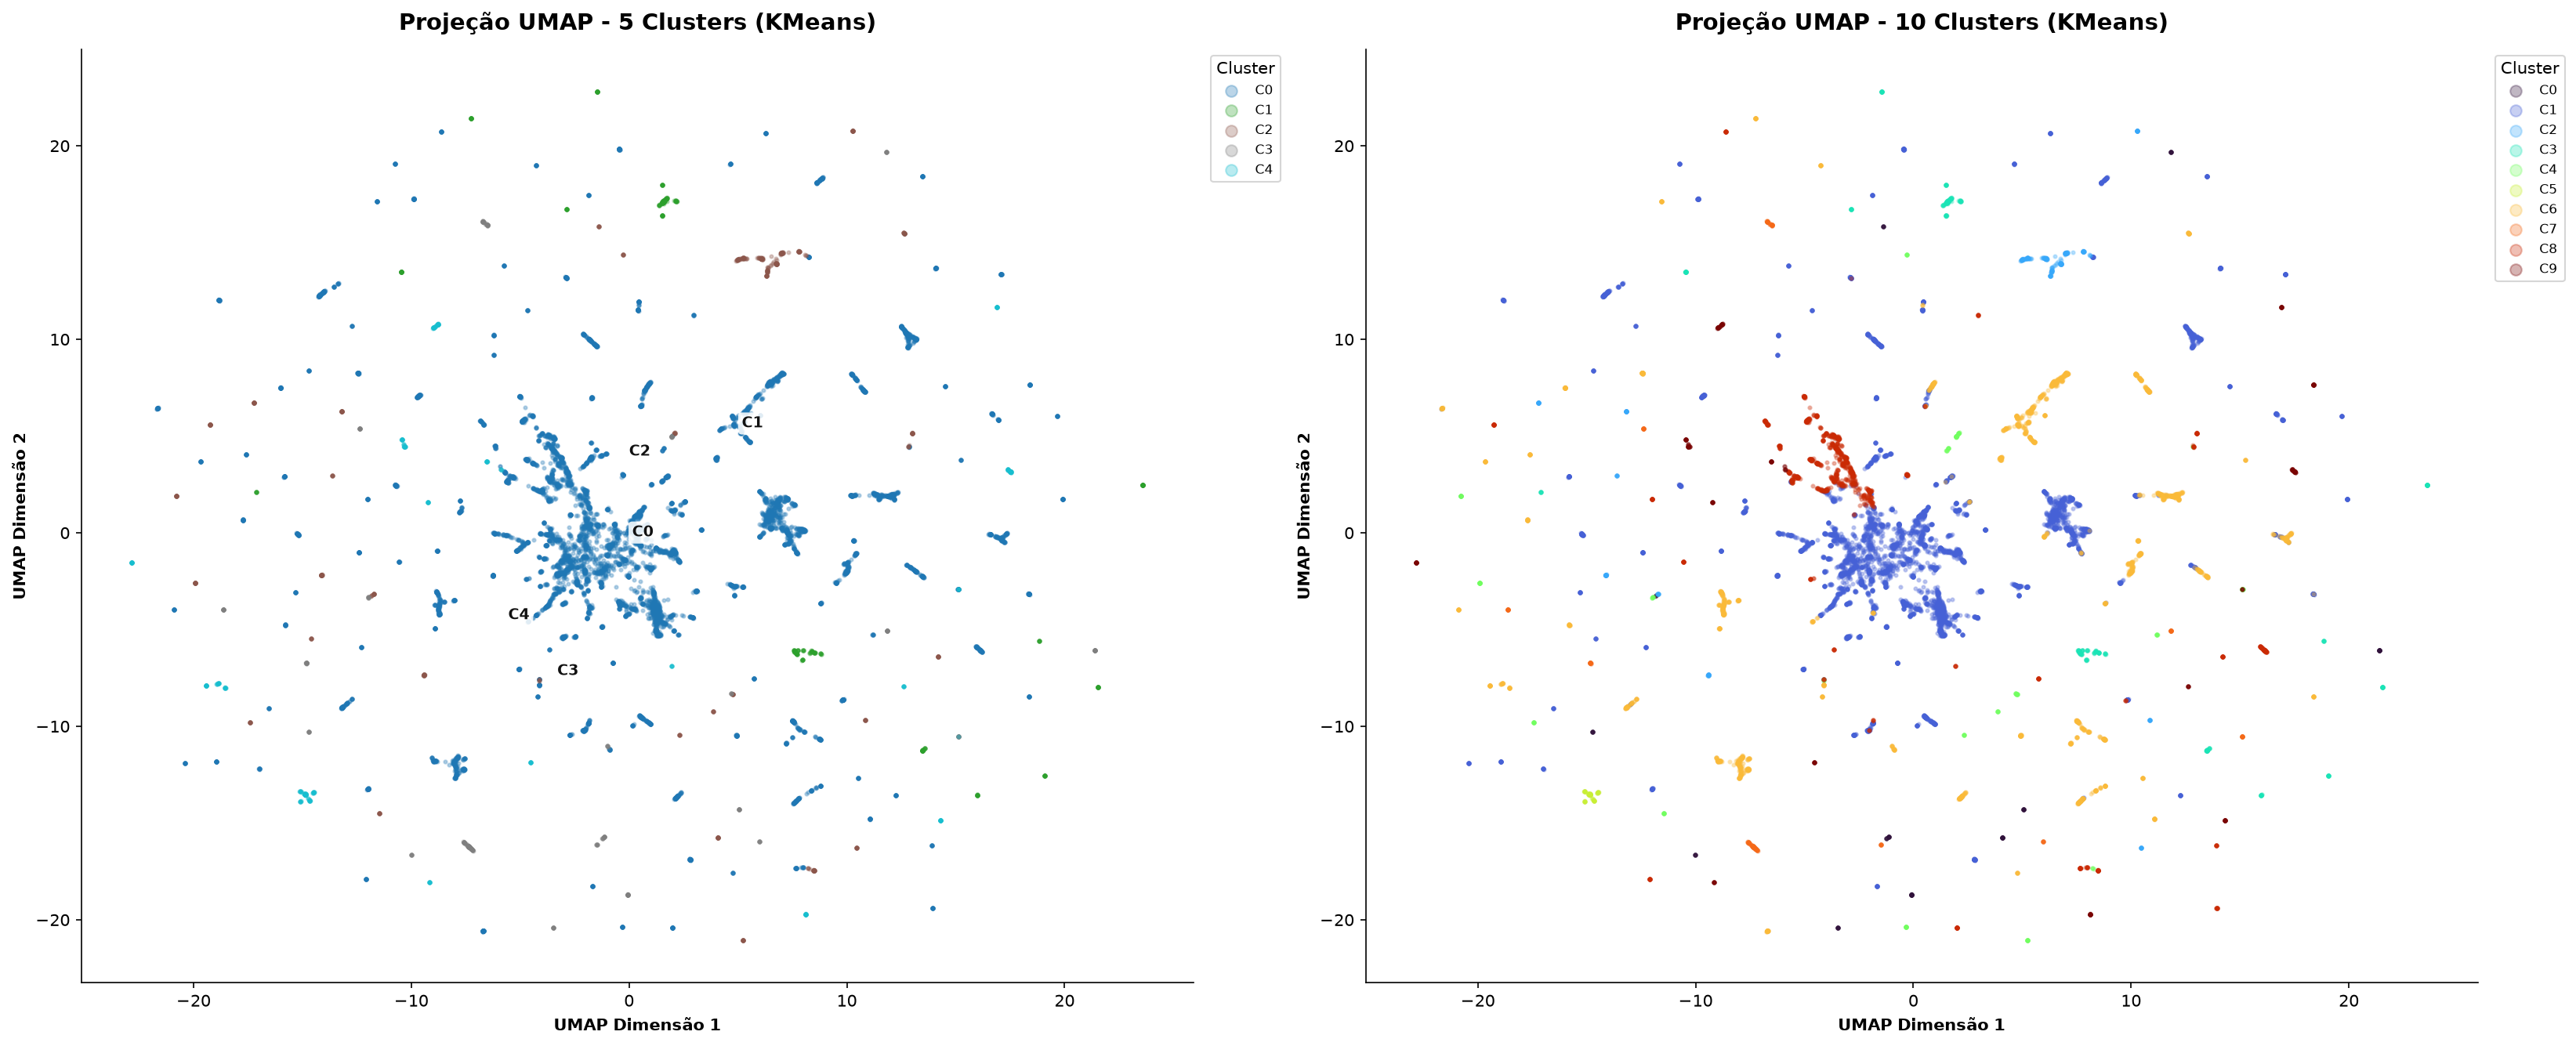

In [28]:
df_sample = df_train.iloc[idx].copy()
df_sample["umap_x"] = coords_2d[:, 0]
df_sample["umap_y"] = coords_2d[:, 1]

df_sample["cluster_5k"] = clusters_emb_5k_train[idx]
df_sample["cluster_10k"] = clusters_emb_10k_train[idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9), dpi=150)

configs = [
    {
        "ax": ax1,
        "col_cluster": "cluster_5k",
        "title": "Projeção UMAP - 5 Clusters (KMeans)",
        "cmap": "tab10",
        "show_centroids": True, 
    },
    {
        "ax": ax2,
        "col_cluster": "cluster_10k",
        "title": "Projeção UMAP - 10 Clusters (KMeans)",
        "cmap": "turbo", 
        "show_centroids": False, 
    },
]

for cfg in configs:
    ax = cfg["ax"]
    col = cfg["col_cluster"]
    clusters_unicos = np.sort(df_sample[col].unique())

    cmap = plt.get_cmap(cfg["cmap"])
    colors = cmap(np.linspace(0, 1, len(clusters_unicos)))

    for i, cluster in enumerate(clusters_unicos):
        subset = df_sample[df_sample[col] == cluster]
        ax.scatter(
            subset["umap_x"],
            subset["umap_y"],
            c=[colors[i]],
            label=f"C{cluster}",
            alpha=0.3,
            s=4,
            rasterized=True,
        )

    if cfg["show_centroids"]:
        centroides_2d = df_sample.groupby(col)[["umap_x", "umap_y"]].mean()
        for c_id, row in centroides_2d.iterrows():
            ax.annotate(
                f"C{c_id}",
                (row["umap_x"], row["umap_y"]),
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="#111111",
                bbox=dict(
                    boxstyle="round,pad=0.25", fc="#ffffffdd", ec="none"
                ),
            )

    ax.set_title(cfg["title"], fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("UMAP Dimensão 1", fontsize=10, fontweight="bold")
    ax.set_ylabel("UMAP Dimensão 2", fontsize=10, fontweight="bold")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ncols = 1 if len(clusters_unicos) <= 10 else 2
    ax.legend(
        title="Cluster",
        bbox_to_anchor=(1.01, 1),
        loc="upper left",
        markerscale=3.5,
        ncol=ncols,
        fontsize=8,
    )

plt.tight_layout()
plt.show()

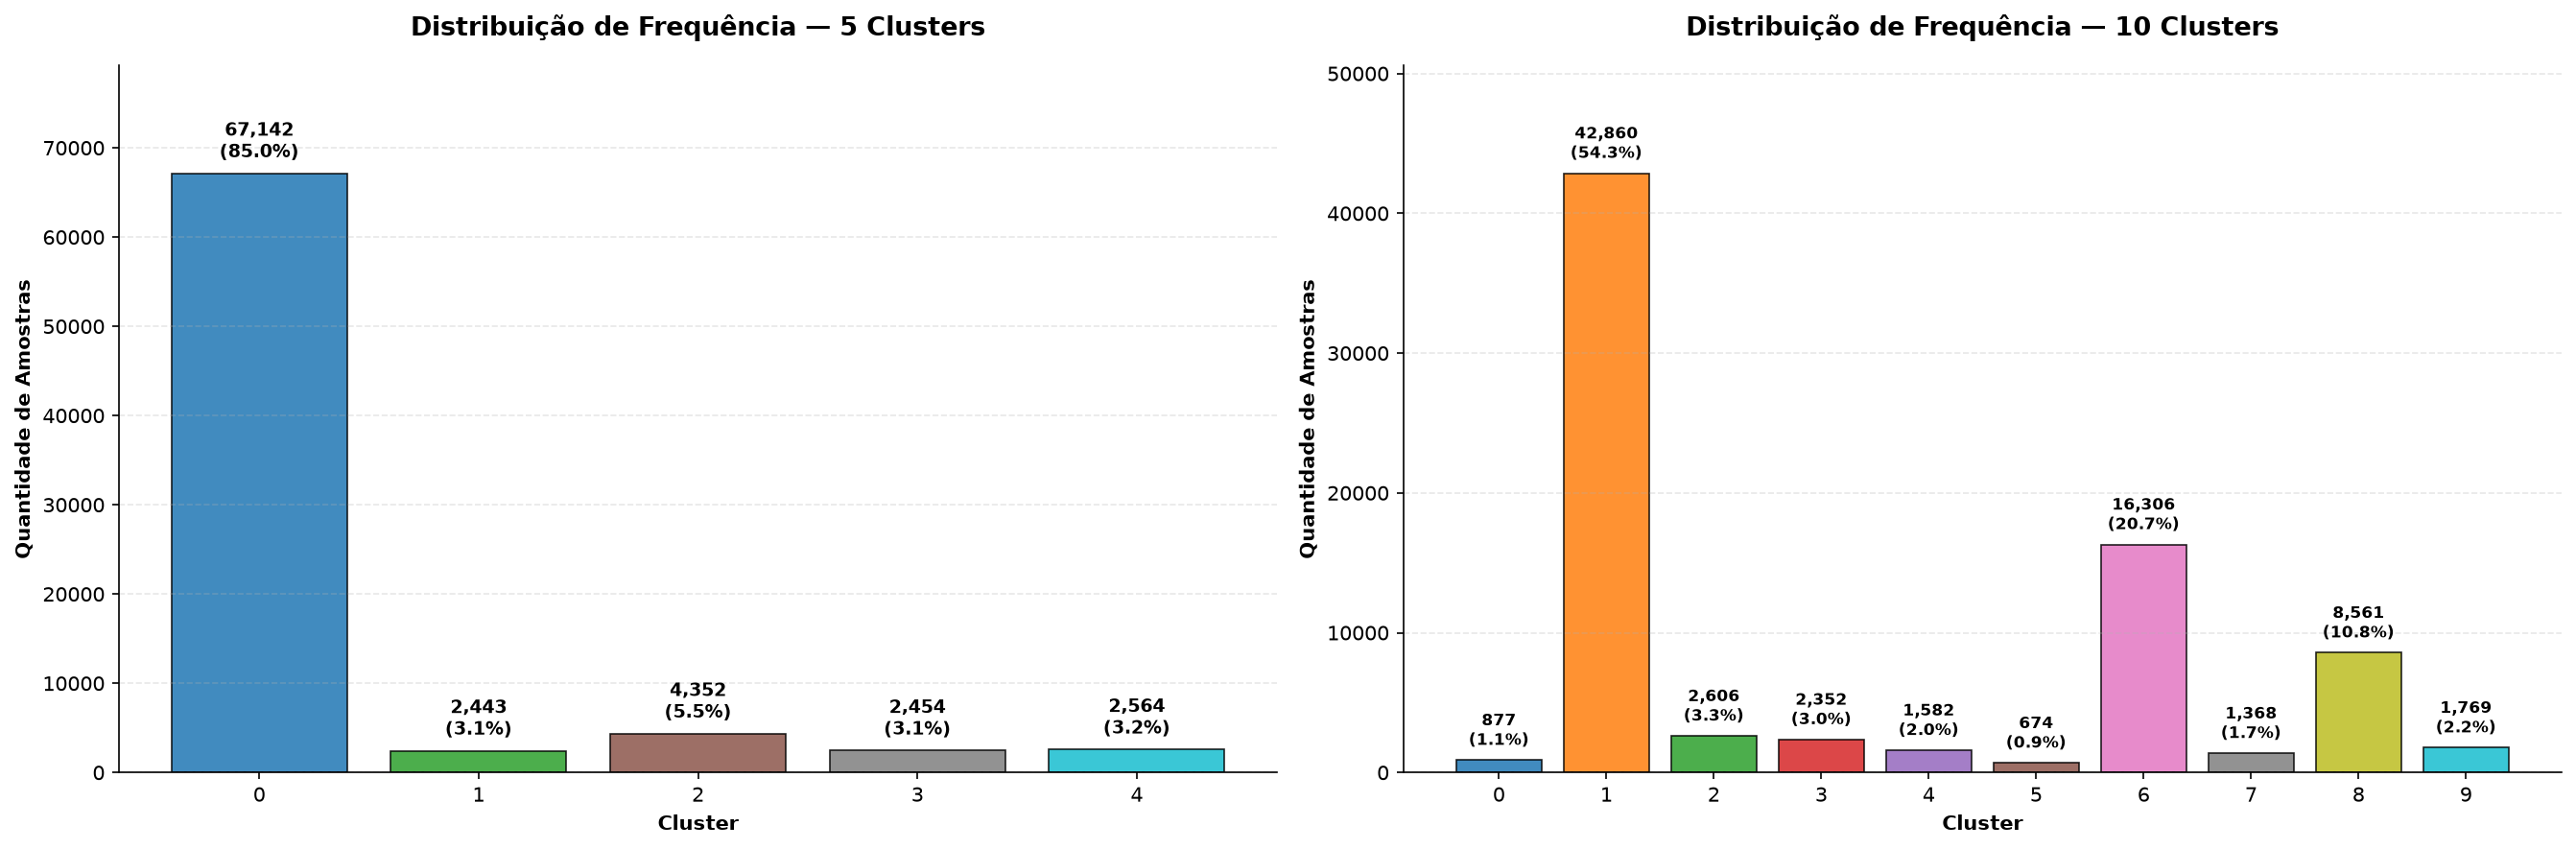

In [ ]:
df_5k = pd.DataFrame({'cluster': clusters_emb_5k_train})
counts_5k = df_5k['cluster'].value_counts().sort_index()
props_5k = df_5k['cluster'].value_counts(normalize=True).sort_index() * 100

df_10k = pd.DataFrame({'cluster': clusters_emb_10k_train})
counts_10k = df_10k['cluster'].value_counts().sort_index()
props_10k = df_10k['cluster'].value_counts(normalize=True).sort_index() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), dpi=150)

# --- Gráfico K = 5 ---
bars1 = ax1.bar(
    counts_5k.index.astype(str),
    counts_5k.values,
    color=plt.cm.tab10(np.linspace(0, 1, 5)),
    edgecolor="black",
    linewidth=0.8,
    alpha=0.85
)

for bar, count, prop in zip(bars1, counts_5k.values, props_5k.values):
    height = bar.get_height()
    ax1.annotate(
        f"{count:,}\n({prop:.1f}%)",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax1.set_title("Distribuição de Frequência — 5 Clusters", fontsize=13, fontweight="bold", pad=15)
ax1.set_xlabel("Cluster", fontsize=10, fontweight="bold")
ax1.set_ylabel("Quantidade de Amostras", fontsize=10, fontweight="bold")
ax1.set_ylim(0, max(counts_5k.values) * 1.18)  

# --- Gráfico K = 10 ---
bars2 = ax2.bar(
    counts_10k.index.astype(str),
    counts_10k.values,
    color=plt.cm.tab10(np.linspace(0, 1, 10)),
    edgecolor="black",
    linewidth=0.8,
    alpha=0.85
)

for bar, count, prop in zip(bars2, counts_10k.values, props_10k.values):
    height = bar.get_height()
    ax2.annotate(
        f"{count:,}\n({prop:.1f}%)",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='bold'
    )

ax2.set_title("Distribuição de Frequência — 10 Clusters", fontsize=13, fontweight="bold", pad=15)
ax2.set_xlabel("Cluster", fontsize=10, fontweight="bold")
ax2.set_ylabel("Quantidade de Amostras", fontsize=10, fontweight="bold")
ax2.set_ylim(0, max(counts_10k.values) * 1.18)

for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

Como os clusters ficaram terrivelmente mal distribuídos, vamos tentar outra abordagem.

In [47]:
import hdbscan

hdb = hdbscan.HDBSCAN(
    min_cluster_size=500,
    min_samples=20,
    cluster_selection_method="eom",
    prediction_data=True
)


clusters_hdb_emb_train = hdb.fit_predict(umap_train_emb)

In [48]:
df_hdb_emb = pd.DataFrame({'cluster': clusters_hdb_emb_train})
counts_hdb_emb = df_hdb_emb['cluster'].value_counts().sort_index()
props_hdb_emb = df_hdb_emb['cluster'].value_counts(normalize=True).sort_index() * 100

qtd_ruido_emb = counts_hdb_emb.get(-1, 0)
prop_ruido_emb = props_hdb_emb.get(-1, 0.0)

print(f"Total de Ruído / Outliers (Cluster -1): {qtd_ruido_emb:,} ({prop_ruido_emb:.2f}%)")
print(f"Total de Clusters Válidos Encontrados: {len(counts_hdb_emb[counts_hdb_emb.index != -1])}")

Total de Ruído / Outliers (Cluster -1): 8,728 (11.05%)
Total de Clusters Válidos Encontrados: 6


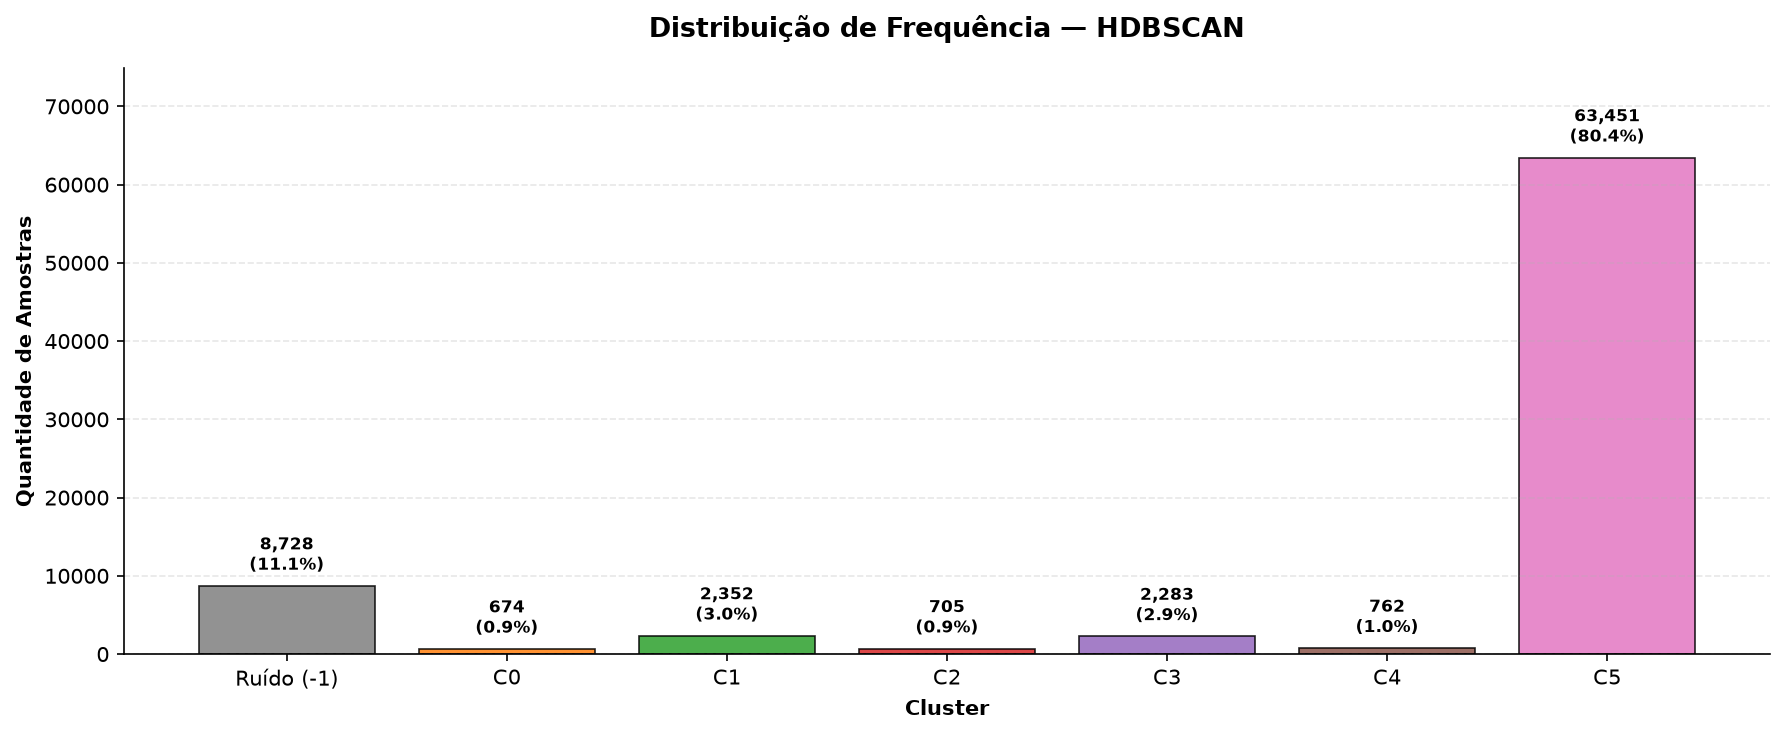

In [49]:
plt.figure(figsize=(12, 5), dpi=150)

labels = [f"C{c}" if c != -1 else "Ruído (-1)" for c in counts_hdb_emb.index]
colors = ['#7f7f7f' if c == -1 else plt.cm.tab10(i % 10) for i, c in enumerate(counts_hdb_emb.index)]

bars = plt.bar(
    labels,
    counts_hdb_emb.values,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.85
)

for bar, count, prop in zip(bars, counts_hdb_emb.values, props_hdb_emb.values):
    height = bar.get_height()
    plt.annotate(
        f"{count:,}\n({prop:.1f}%)",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='bold'
    )

plt.title("Distribuição de Frequência — HDBSCAN", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Cluster", fontsize=10, fontweight="bold")
plt.ylabel("Quantidade de Amostras", fontsize=10, fontweight="bold")
plt.ylim(0, max(counts_hdb_emb.values) * 1.18)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Não houve muita melhora, vamos forçar mais clusters com KMeans, entre 20 e 25 que tiveram maior pontuação.

In [50]:
# 20 Clusters

kmeans_emb_20k = MiniBatchKMeans(
    n_clusters=20,
    batch_size=2048,
    random_state=42,
    n_init=10
)

clusters_emb_20k_train = kmeans_emb_20k.fit_predict(umap_train_emb)
clusters_emb_20k_test = kmeans_emb_20k.predict(umap_test_emb)

# 25 Clusters

kmeans_emb_25k = MiniBatchKMeans(
    n_clusters=25,
    batch_size=2048,
    random_state=42,
    n_init=10
)

clusters_emb_25k_train = kmeans_emb_25k.fit_predict(umap_train_emb)
clusters_emb_25k_test = kmeans_emb_25k.predict(umap_test_emb)

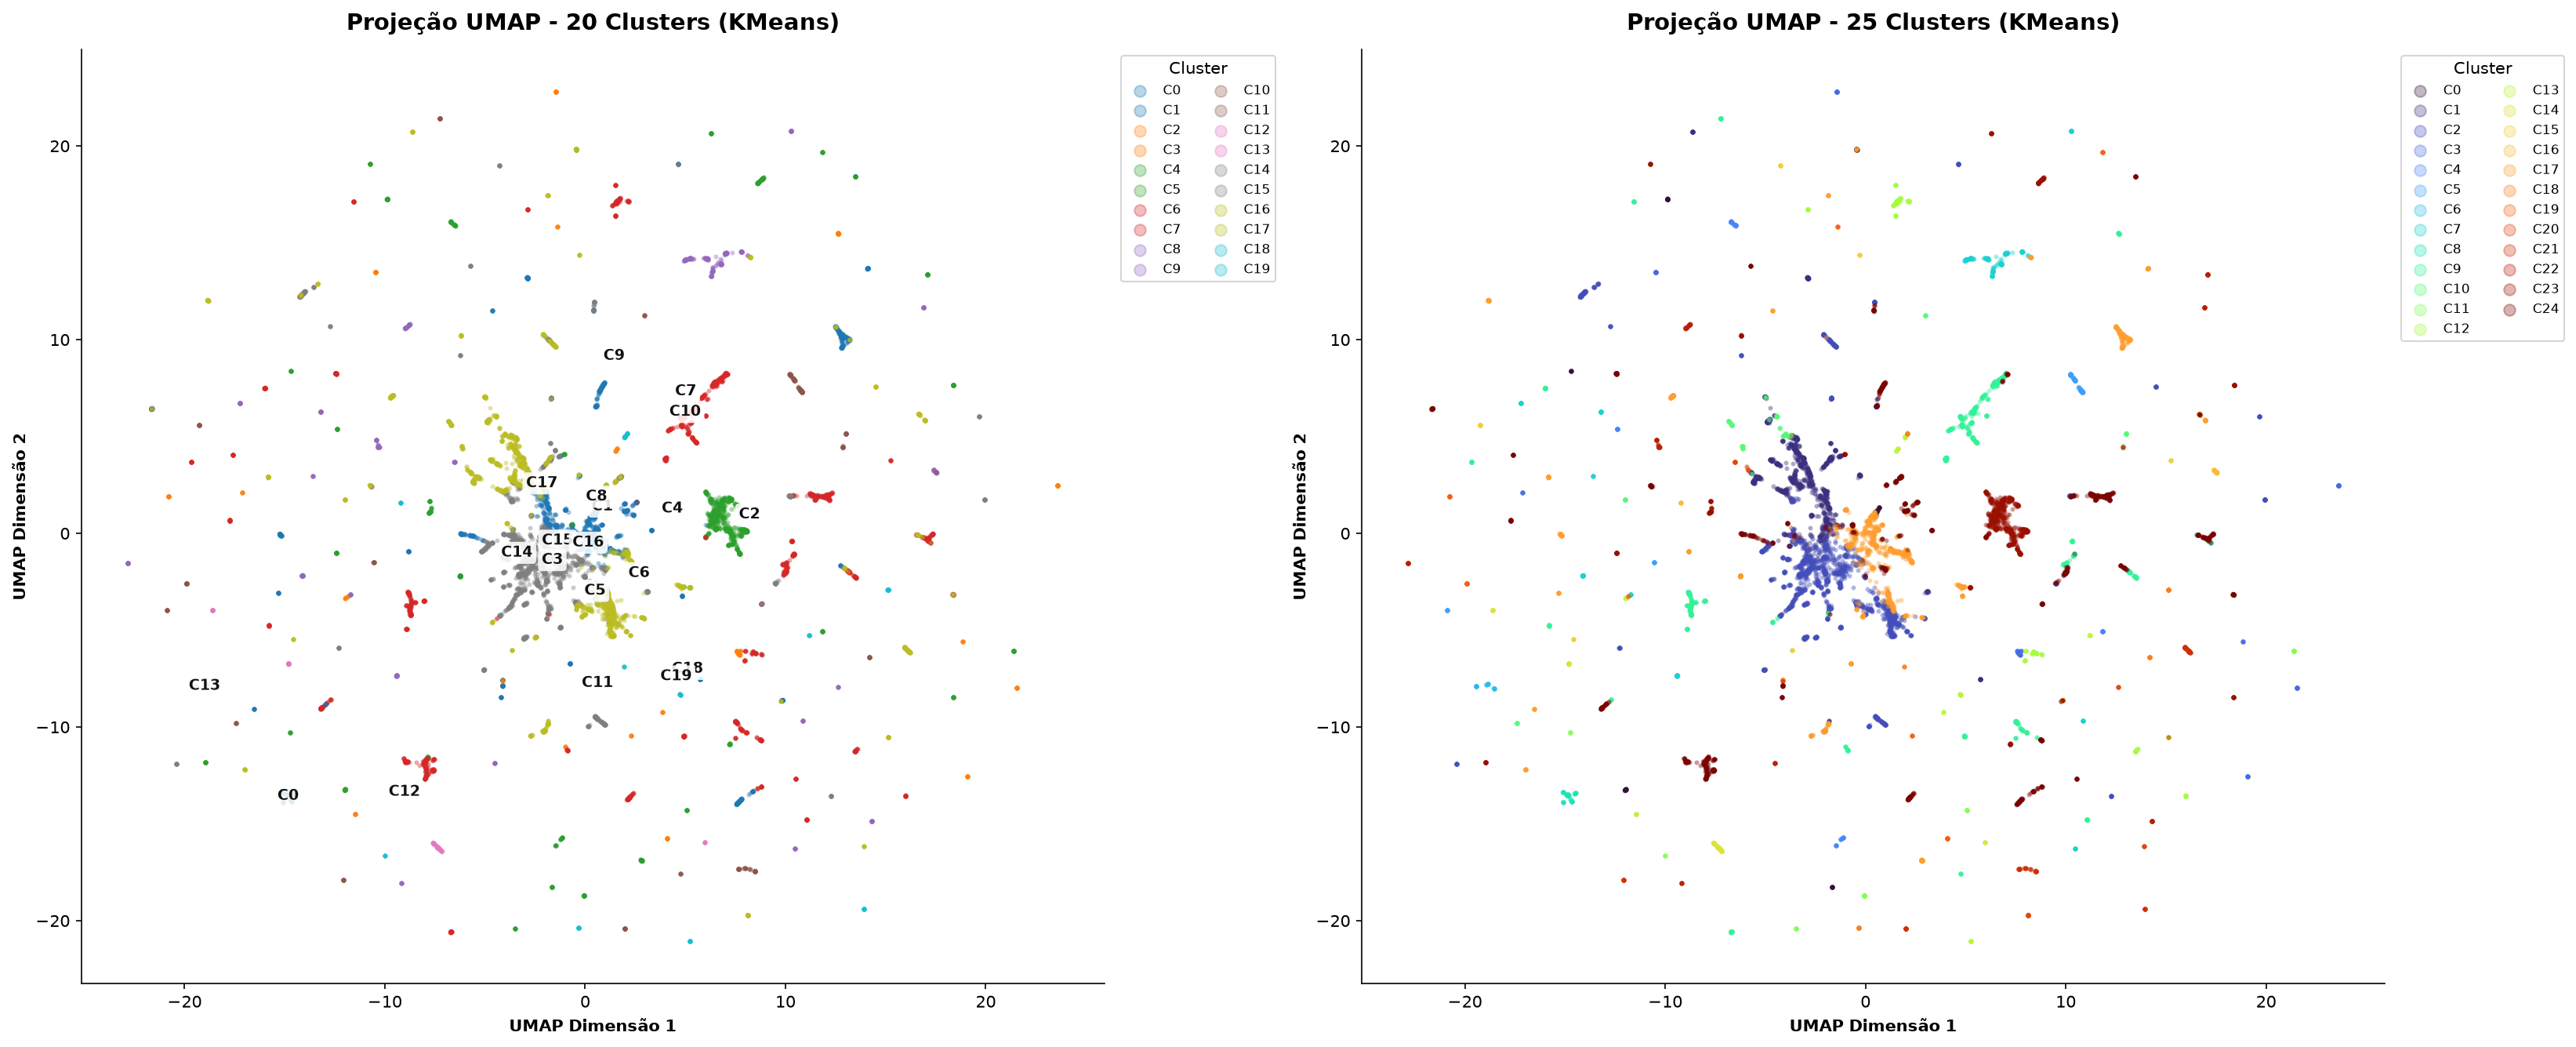

In [51]:
df_sample["cluster_20k"] = clusters_emb_20k_train[idx]
df_sample["cluster_25k"] = clusters_emb_25k_train[idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9), dpi=150)

configs = [
    {
        "ax": ax1,
        "col_cluster": "cluster_20k",
        "title": "Projeção UMAP - 20 Clusters (KMeans)",
        "cmap": "tab10",
        "show_centroids": True, 
    },
    {
        "ax": ax2,
        "col_cluster": "cluster_25k",
        "title": "Projeção UMAP - 25 Clusters (KMeans)",
        "cmap": "turbo", 
        "show_centroids": False, 
    },
]

for cfg in configs:
    ax = cfg["ax"]
    col = cfg["col_cluster"]
    clusters_unicos = np.sort(df_sample[col].unique())

    cmap = plt.get_cmap(cfg["cmap"])
    colors = cmap(np.linspace(0, 1, len(clusters_unicos)))

    for i, cluster in enumerate(clusters_unicos):
        subset = df_sample[df_sample[col] == cluster]
        ax.scatter(
            subset["umap_x"],
            subset["umap_y"],
            c=[colors[i]],
            label=f"C{cluster}",
            alpha=0.3,
            s=4,
            rasterized=True,
        )

    if cfg["show_centroids"]:
        centroides_2d = df_sample.groupby(col)[["umap_x", "umap_y"]].mean()
        for c_id, row in centroides_2d.iterrows():
            ax.annotate(
                f"C{c_id}",
                (row["umap_x"], row["umap_y"]),
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="#111111",
                bbox=dict(
                    boxstyle="round,pad=0.25", fc="#ffffffdd", ec="none"
                ),
            )

    ax.set_title(cfg["title"], fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("UMAP Dimensão 1", fontsize=10, fontweight="bold")
    ax.set_ylabel("UMAP Dimensão 2", fontsize=10, fontweight="bold")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ncols = 1 if len(clusters_unicos) <= 10 else 2
    ax.legend(
        title="Cluster",
        bbox_to_anchor=(1.01, 1),
        loc="upper left",
        markerscale=3.5,
        ncol=ncols,
        fontsize=8,
    )

plt.tight_layout()
plt.show()

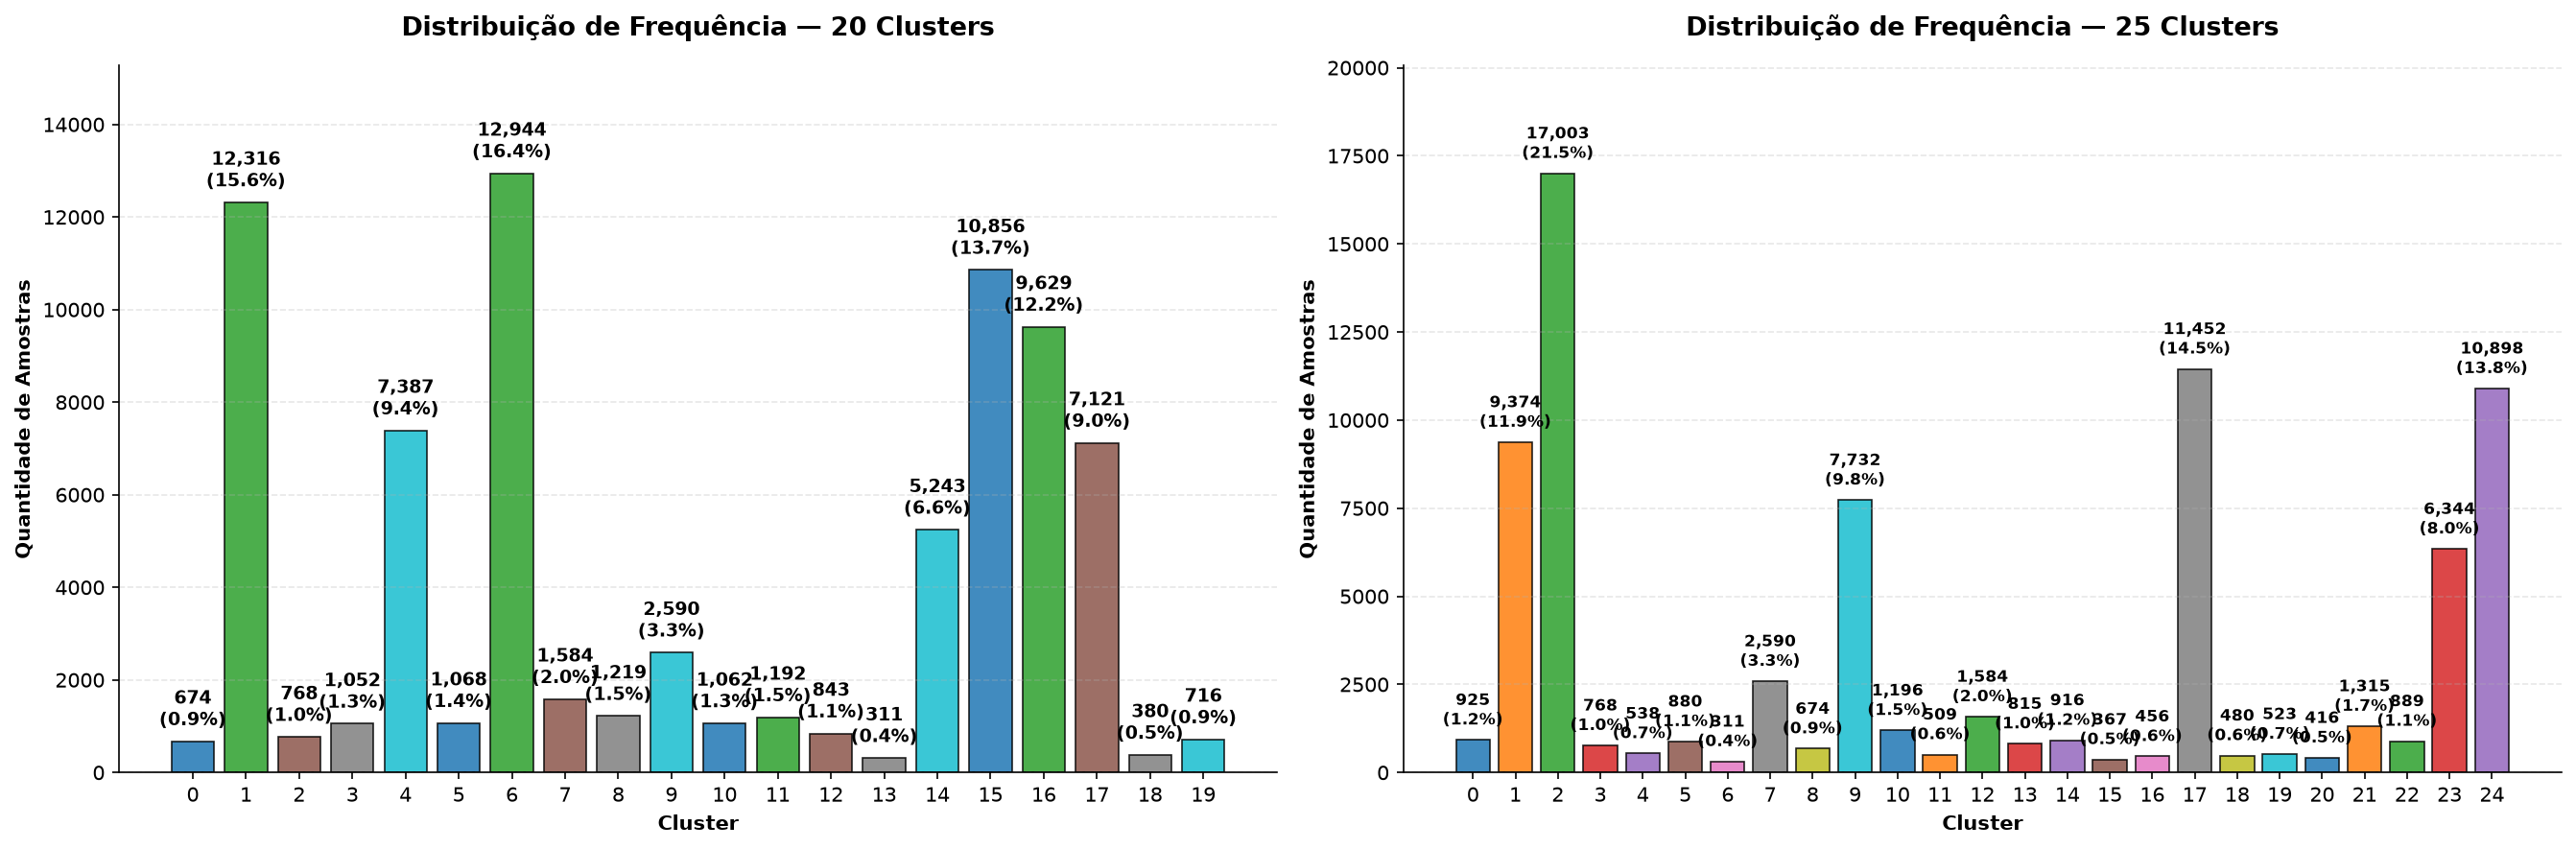

In [53]:
df_20k = pd.DataFrame({'cluster': clusters_emb_20k_train})
counts_20k = df_20k['cluster'].value_counts().sort_index()
props_20k = df_20k['cluster'].value_counts(normalize=True).sort_index() * 100

df_25k = pd.DataFrame({'cluster': clusters_emb_25k_train})
counts_25k = df_25k['cluster'].value_counts().sort_index()
props_25k = df_25k['cluster'].value_counts(normalize=True).sort_index() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), dpi=150)

# --- Gráfico K = 5 ---
bars1 = ax1.bar(
    counts_20k.index.astype(str),
    counts_20k.values,
    color=plt.cm.tab10(np.linspace(0, 1, 5)),
    edgecolor="black",
    linewidth=0.8,
    alpha=0.85
)

for bar, count, prop in zip(bars1, counts_20k.values, props_20k.values):
    height = bar.get_height()
    ax1.annotate(
        f"{count:,}\n({prop:.1f}%)",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax1.set_title("Distribuição de Frequência — 20 Clusters", fontsize=13, fontweight="bold", pad=15)
ax1.set_xlabel("Cluster", fontsize=10, fontweight="bold")
ax1.set_ylabel("Quantidade de Amostras", fontsize=10, fontweight="bold")
ax1.set_ylim(0, max(counts_20k.values) * 1.18)  

# --- Gráfico K = 10 ---
bars2 = ax2.bar(
    counts_25k.index.astype(str),
    counts_25k.values,
    color=plt.cm.tab10(np.linspace(0, 1, 10)),
    edgecolor="black",
    linewidth=0.8,
    alpha=0.85
)

for bar, count, prop in zip(bars2, counts_25k.values, props_25k.values):
    height = bar.get_height()
    ax2.annotate(
        f"{count:,}\n({prop:.1f}%)",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='bold'
    )

ax2.set_title("Distribuição de Frequência — 25 Clusters", fontsize=13, fontweight="bold", pad=15)
ax2.set_xlabel("Cluster", fontsize=10, fontweight="bold")
ax2.set_ylabel("Quantidade de Amostras", fontsize=10, fontweight="bold")
ax2.set_ylim(0, max(counts_25k.values) * 1.18)

for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

In [55]:
import joblib

# Salvando arrays de teste, treino e modelo 20 clusters 

np.save(
    "../artifacts/clustering/clusters_train_20.npy",
    clusters_emb_20k_train
)

np.save(
    "../artifacts/clustering/clusters_test_20.npy",
    clusters_emb_20k_test
)

joblib.dump(
    kmeans_emb_20k,
    "../artifacts/clustering/kmeans_20.joblib"
)

# Salvando arrays de teste, treino e modelo 25 clusters 


np.save(
    "../artifacts/clustering/clusters_train_25.npy",
    clusters_emb_25k_train
)

np.save(
    "../artifacts/clustering/clusters_test_25.npy",
    clusters_emb_25k_test
)

joblib.dump(
    kmeans_emb_25k,
    "../artifacts/clustering/kmeans_25.joblib"
)

['../artifacts/clustering/kmeans_25.joblib']

In [ ]:
# Salvando o modelo Umap

joblib.dump(
    umap_cluster_embedding,
    "../artifacts/clustering/umap_cluster.joblib"
)

['../artifacts/clustering/umap_cluster.joblib']